# 📚 Lecture: Regularization in Machine Learning
### Building on Linear Regression → Ridge & Lasso

---

### 👩‍🎓 Student Details:
- **Name:** Qalb E Zahra Mashhadi  
- **Date:** April 15, 2026  
- **Role:** AI/ML Engineer (Transitioning)  
- **Program:** NETSOL & NIAI (NAVTTC) Training  
---

### 📌 Prerequisites: You already know:
- Simple Linear Regression (1 variable)  
- Multivariate Linear Regression (many variables)  

---

### 🎯 What we'll learn today:
1. 🤔 What is Overfitting & Underfitting?  
2. ⚖️ Bias vs Variance (The Big Trade-off)  
3. 🔧 What is Regularization and WHY do we need it?  
4. 🔵 Ridge Regression (L2)  
5. 🟡 Lasso Regression (L1)  
6. 📊 Ridge vs Lasso — When to use which?

---

In [1]:
# 📦 Import all required libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_regression
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Nice plot style
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


---
## 🧩 Part 1: The Problem — Overfitting & Underfitting

### 🔑 Key Idea

You already know that in Linear Regression, we find the **best line** that fits the data.

But what if the model fits the **training data TOO well** — so well that it can't predict **new data** properly?

Let's see this with an example.

### 🎯 Analogy:
Imagine a student studying for exams:
- **Underfitting** = Student didn't study at all → Fails both practice tests AND the real exam
- **Just Right** = Student studied well → Does well on both
- **Overfitting** = Student memorized ONLY the practice questions → Fails the real exam because the questions are slightly different!

---

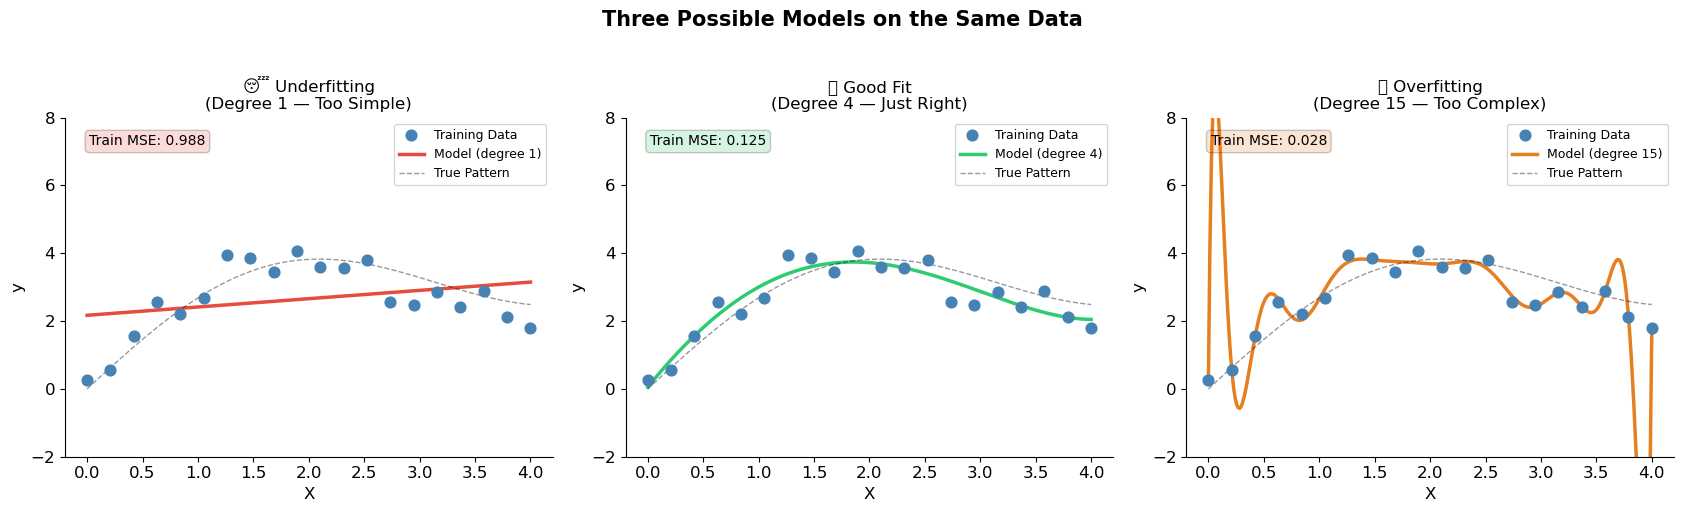


📝 OBSERVATIONS:
─────────────────────────────────────────────────────
🔴 Underfitting  → Line is too straight. Misses the pattern.
                   High error on BOTH train & new data.

🟢 Good Fit      → Captures the shape well without chasing noise.
                   Low error on train AND new data.

🟠 Overfitting   → Wiggles to hit every single data point.
                   Very low train error, but TERRIBLE on new data!
─────────────────────────────────────────────────────



In [2]:
# ============================================================
# 📊 DEMO 1: Visualizing Underfitting, Good Fit, Overfitting
# ============================================================

# Generate some "true" data: a slightly curved pattern with noise
np.random.seed(42)
n = 20
X = np.linspace(0, 4, n)
y_true = 2 * np.sin(X) + X          # True pattern (sine wave + linear trend)
y = y_true + np.random.normal(0, 0.5, n)  # Add noise (real-world messiness)

X_plot = np.linspace(0, 4, 300)      # Smooth X for drawing curves

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Three Possible Models on the Same Data', fontsize=15, fontweight='bold', y=1.02)

titles = ['😴 Underfitting\n(Degree 1 — Too Simple)',
          '✅ Good Fit\n(Degree 4 — Just Right)',
          '🤯 Overfitting\n(Degree 15 — Too Complex)']
degrees = [1, 4, 15]
colors  = ['#e74c3c', '#2ecc71', '#e67e22']

for ax, deg, title, color in zip(axes, degrees, titles, colors):
    # Fit polynomial of given degree
    coeffs = np.polyfit(X, y, deg)
    poly   = np.poly1d(coeffs)
    
    # Training error
    train_err = np.mean((y - poly(X))**2)
    
    # Plot
    ax.scatter(X, y, color='steelblue', s=60, zorder=5, label='Training Data')
    ax.plot(X_plot, poly(X_plot), color=color, linewidth=2.5, label=f'Model (degree {deg})')
    ax.plot(X_plot, 2*np.sin(X_plot)+X_plot, 'k--', linewidth=1, alpha=0.4, label='True Pattern')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('X')
    ax.set_ylabel('y')
    ax.set_ylim(-2, 8)
    ax.legend(fontsize=9)
    ax.text(0.05, 0.95, f'Train MSE: {train_err:.3f}', transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor=color, alpha=0.2))

plt.tight_layout()
plt.show()

print("""
📝 OBSERVATIONS:
─────────────────────────────────────────────────────
🔴 Underfitting  → Line is too straight. Misses the pattern.
                   High error on BOTH train & new data.

🟢 Good Fit      → Captures the shape well without chasing noise.
                   Low error on train AND new data.

🟠 Overfitting   → Wiggles to hit every single data point.
                   Very low train error, but TERRIBLE on new data!
─────────────────────────────────────────────────────
""")

---
## ⚖️ Part 2: Bias vs Variance

These are two types of errors that any model can make.

| Term | Simple Meaning | Caused By |
|------|---------------|----------|
| **Bias** | How far off is the model FROM the truth *on average*? | Model too simple (Underfitting) |
| **Variance** | How much does the model CHANGE when we use different training data? | Model too complex (Overfitting) |

### 🎯 Dart Board Analogy:
Imagine throwing darts at a target:
- **High Bias** = All darts land far from center (consistently wrong)
- **High Variance** = Darts are scattered everywhere (inconsistent)
- **Low Bias + Low Variance** = Darts cluster near the center ✅

### The Golden Rule:
> **As model complexity increases → Bias ↓ but Variance ↑**  
> **As model complexity decreases → Variance ↓ but Bias ↑**  
> We need to find the **sweet spot** in the middle!

---

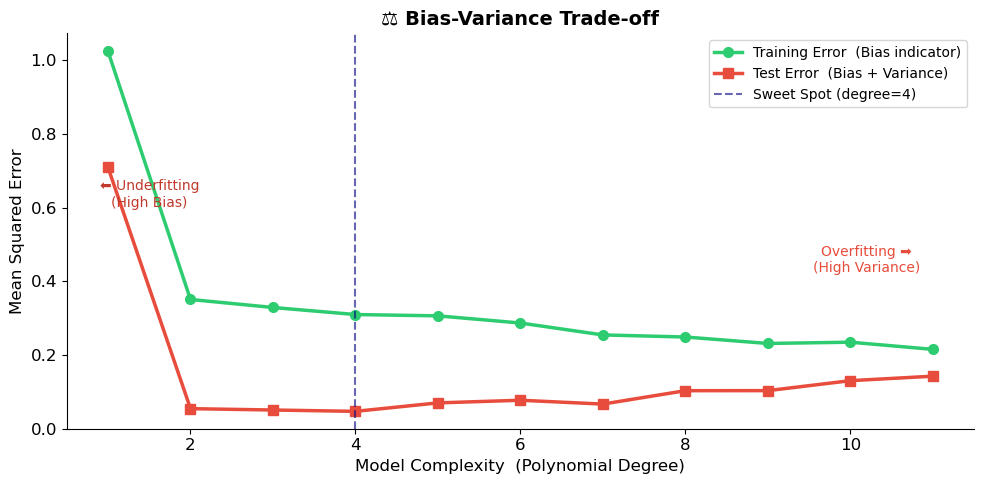


📝 KEY TAKEAWAY:
─────────────────────────────────────────────────────────────────
  Training error ALWAYS goes down as we add complexity.
  But Test error goes down THEN back up again (U-shape).

  The lowest point of the Test error curve = SWEET SPOT!
  ➡ This is what Regularization helps us find automatically.
─────────────────────────────────────────────────────────────────



In [3]:
# ============================================================
# 🎯 DEMO 2: Bias-Variance Trade-off Curve
# ============================================================

np.random.seed(42)

# We'll use polynomial degree as a proxy for model complexity
degrees = range(1, 12)
n_experiments = 50   # Train the same degree model 50 times on different data samples
n_points = 30

X_base = np.linspace(0, 4, n_points)
X_test = np.linspace(0, 4, 200)
y_test_true = 2 * np.sin(X_test) + X_test

train_errors = []
test_errors  = []

for deg in degrees:
    train_errs_exp = []
    test_errs_exp  = []
    
    for _ in range(n_experiments):
        # Different noise each experiment (simulates different datasets)
        y_noisy = 2*np.sin(X_base) + X_base + np.random.normal(0, 0.6, n_points)
        
        # Fit polynomial
        coeffs = np.polyfit(X_base, y_noisy, deg)
        poly   = np.poly1d(coeffs)
        
        # Errors
        train_errs_exp.append(np.mean((y_noisy - poly(X_base))**2))
        test_errs_exp.append(np.mean((y_test_true - poly(X_test))**2))
    
    train_errors.append(np.mean(train_errs_exp))
    test_errors.append(np.mean(test_errs_exp))

# ── Plot ──────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(list(degrees), train_errors, 'o-', color='#2ecc71', linewidth=2.5,
         markersize=7, label='Training Error  (Bias indicator)')
plt.plot(list(degrees), test_errors,  's-', color='#e74c3c', linewidth=2.5,
         markersize=7, label='Test Error  (Bias + Variance)')

# Mark sweet spot
best_deg = list(degrees)[np.argmin(test_errors)]
plt.axvline(x=best_deg, color='navy', linestyle='--', alpha=0.6, label=f'Sweet Spot (degree={best_deg})')

# Annotate regions
plt.annotate('⬅ Underfitting\n(High Bias)', xy=(1.5, max(test_errors)*0.85),
             fontsize=10, color='#c0392b', ha='center')
plt.annotate('Overfitting ➡\n(High Variance)', xy=(10.2, max(test_errors)*0.6),
             fontsize=10, color='#e74c3c', ha='center')

plt.xlabel('Model Complexity  (Polynomial Degree)', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('⚖️ Bias-Variance Trade-off', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

print("""
📝 KEY TAKEAWAY:
─────────────────────────────────────────────────────────────────
  Training error ALWAYS goes down as we add complexity.
  But Test error goes down THEN back up again (U-shape).

  The lowest point of the Test error curve = SWEET SPOT!
  ➡ This is what Regularization helps us find automatically.
─────────────────────────────────────────────────────────────────
""")

---
## 🔧 Part 3: What is Regularization?

### The Problem with Plain Linear Regression

In multivariate linear regression, we have:

$$\hat{y} = w_0 + w_1 x_1 + w_2 x_2 + \ldots + w_n x_n$$

We minimize the **Loss Function (MSE)**:
$$\text{Loss} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

**The problem:** When a model overfits, the weights $w_1, w_2, \ldots$ become **very large** to fit every data point exactly. Large weights = model is too "sensitive" to tiny changes in X.

### ✅ Solution: Add a Penalty for Large Weights!

Regularization says: **"Minimize the loss, BUT ALSO keep the weights small!"**

$$\text{New Loss} = \underbrace{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}_{\text{Fit the data}} + \underbrace{\lambda \cdot \text{Penalty on weights}}_{\text{Keep weights small}}$$

- **$\lambda$ (lambda)** = controls how much we penalize large weights
  - High $\lambda$ → Strong penalty → Weights shrink a lot → Simpler model
  - Low $\lambda$ → Weak penalty → Closer to plain linear regression
  - $\lambda = 0$ → No penalty → Exactly plain linear regression

---

## 🔵 Ridge Regression (L2 Regularization)

**Penalty = Sum of SQUARED weights**

$$\text{Ridge Loss} = \frac{1}{n}\sum(y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{n} w_j^2$$

- Squares each weight → **No weight ever becomes exactly 0**
- All features are kept, but their influence is **shrunk**
- Think of it as: *"Keep everyone in the team, but reduce their playing time"*

## 🟡 Lasso Regression (L1 Regularization)

**Penalty = Sum of ABSOLUTE weights**

$$\text{Lasso Loss} = \frac{1}{n}\sum(y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{n} |w_j|$$

- Absolute value → Some weights **become exactly 0**
- Features with weight = 0 are **completely removed**
- Think of it as: *"Cut some players from the team entirely"*
- This is called **automatic feature selection** ✨

---

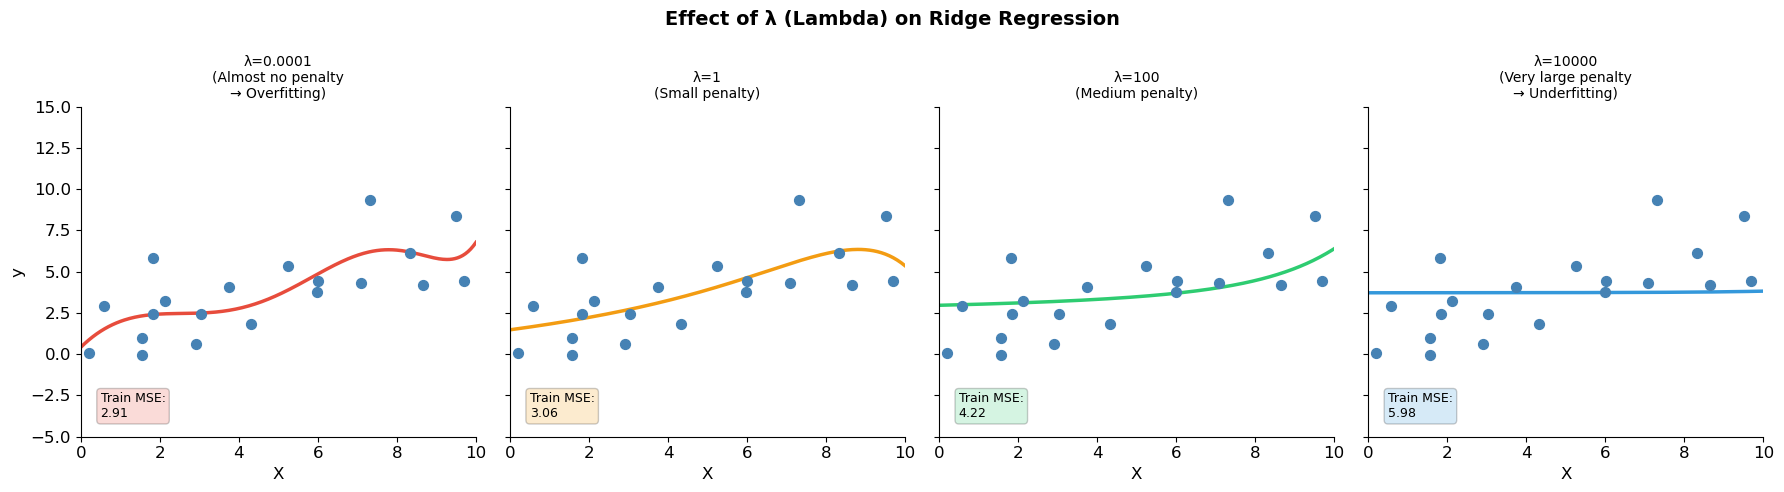


📝 NOTICE:
──────────────────────────────────────────────────────────────
  Small λ  → Curve wiggles wildly to fit every point (overfit)
  Right λ  → Smooth curve that captures the real trend
  Large λ  → Almost flat line (underfit, too much penalty)

  ➡ Choosing the right λ is the key skill in regularization!
──────────────────────────────────────────────────────────────



In [4]:
# ============================================================
# 🔧 DEMO 3: How Lambda Controls Model Complexity (Ridge)
# ============================================================

np.random.seed(42)
n = 20
X_train = np.sort(np.random.uniform(0, 10, n))
y_train = 0.5 * X_train + 2 + np.random.normal(0, 2, n)

X_plot = np.linspace(0, 10, 300).reshape(-1, 1)

# We'll use degree-10 polynomial features to create an overfit-prone setup
degree = 10

lambdas = [0.0001, 1, 100, 10000]
labels  = ['λ=0.0001\n(Almost no penalty\n→ Overfitting)', 
           'λ=1\n(Small penalty)',
           'λ=100\n(Medium penalty)',
           'λ=10000\n(Very large penalty\n→ Underfitting)']
colors  = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
fig.suptitle('Effect of λ (Lambda) on Ridge Regression', fontsize=14, fontweight='bold')

for ax, lam, label, color in zip(axes, lambdas, labels, colors):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=lam))
    ])
    model.fit(X_train.reshape(-1,1), y_train)
    y_pred_plot = model.predict(X_plot)
    train_mse   = mean_squared_error(y_train, model.predict(X_train.reshape(-1,1)))
    
    ax.scatter(X_train, y_train, color='steelblue', s=50, zorder=5)
    ax.plot(X_plot, y_pred_plot, color=color, linewidth=2.5)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('X')
    ax.set_ylim(-5, 15)
    ax.set_xlim(0, 10)
    ax.text(0.05, 0.05, f'Train MSE:\n{train_mse:.2f}',
            transform=ax.transAxes, fontsize=9, verticalalignment='bottom',
            bbox=dict(boxstyle='round', facecolor=color, alpha=0.2))

axes[0].set_ylabel('y')
plt.tight_layout()
plt.show()

print("""
📝 NOTICE:
──────────────────────────────────────────────────────────────
  Small λ  → Curve wiggles wildly to fit every point (overfit)
  Right λ  → Smooth curve that captures the real trend
  Large λ  → Almost flat line (underfit, too much penalty)

  ➡ Choosing the right λ is the key skill in regularization!
──────────────────────────────────────────────────────────────
""")

---
## 🔵 Part 4: Ridge in Action — Multivariate Example

Ridge is especially useful when you have **many features** and some of them may be correlated (related to each other). Ridge **keeps all features** but shrinks the weights.

---

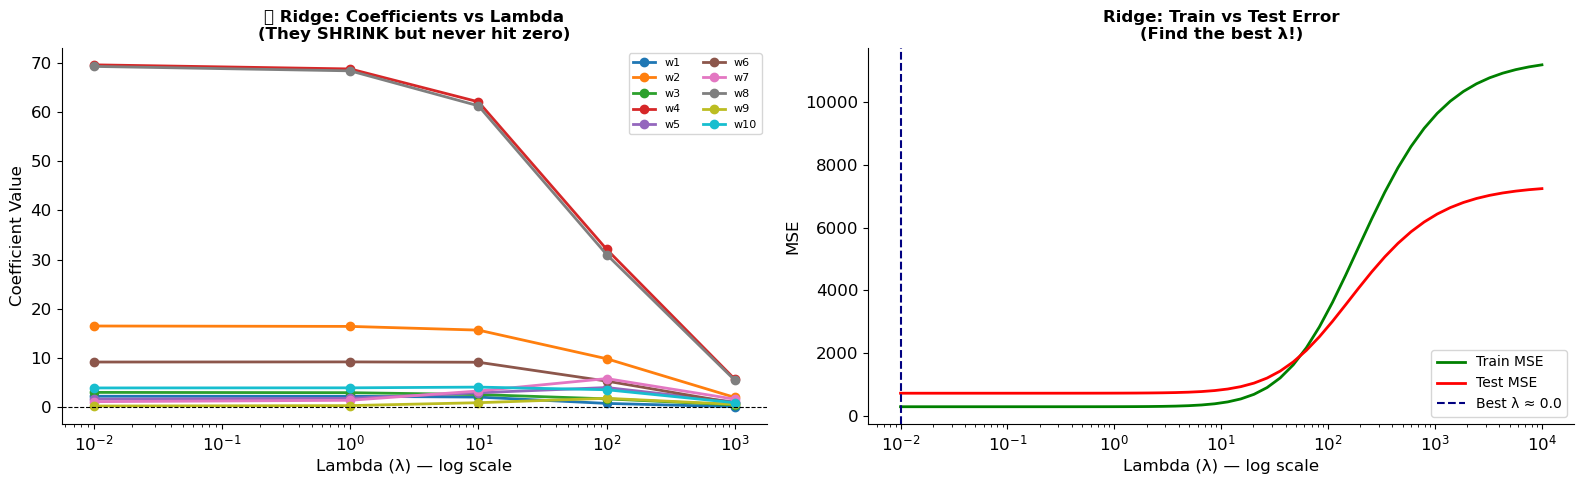


📝 KEY OBSERVATIONS for Ridge:
──────────────────────────────────────────────────────────────
  • As lambda increases, ALL coefficients shrink towards 0.
  • BUT NO coefficient becomes exactly 0. All features stay!
  • Best lambda ≈ 0.0 (lowest test MSE = 722.63)
  • Ridge is great when ALL features matter a little bit.
──────────────────────────────────────────────────────────────



In [5]:
# ============================================================
# 🔵 DEMO 4: Ridge — Effect on Coefficients
# ============================================================

np.random.seed(42)

# Create dataset with 10 features, but only a few truly matter
X, y = make_regression(n_samples=100, n_features=10, n_informative=4,
                       noise=20, random_state=42)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (important for Ridge/Lasso!)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Fit models with different lambda values
alphas = [0.01, 1, 10, 100, 1000]
coefs  = []

for a in alphas:
    r = Ridge(alpha=a)
    r.fit(X_train_s, y_train)
    coefs.append(r.coef_)

# Also fit plain linear regression
lr = LinearRegression()
lr.fit(X_train_s, y_train)

coefs_array = np.array(coefs)  # shape: (n_alphas, n_features)

# ── Plot: how coefficients change as lambda increases ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Left plot: coefficient paths
for i in range(coefs_array.shape[1]):
    ax1.plot(alphas, coefs_array[:, i], 'o-', linewidth=2, label=f'w{i+1}')
ax1.set_xscale('log')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_xlabel('Lambda (λ) — log scale', fontsize=12)
ax1.set_ylabel('Coefficient Value', fontsize=12)
ax1.set_title('🔵 Ridge: Coefficients vs Lambda\n(They SHRINK but never hit zero)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=8, ncol=2, loc='upper right')

# Right plot: train vs test MSE
train_mses, test_mses = [], []
all_alphas = np.logspace(-2, 4, 50)
for a in all_alphas:
    r = Ridge(alpha=a)
    r.fit(X_train_s, y_train)
    train_mses.append(mean_squared_error(y_train, r.predict(X_train_s)))
    test_mses.append(mean_squared_error(y_test,  r.predict(X_test_s)))

best_a   = all_alphas[np.argmin(test_mses)]
best_mse = min(test_mses)

ax2.plot(all_alphas, train_mses, 'g-', linewidth=2, label='Train MSE')
ax2.plot(all_alphas, test_mses,  'r-', linewidth=2, label='Test MSE')
ax2.axvline(best_a, color='navy', linestyle='--', label=f'Best λ ≈ {best_a:.1f}')
ax2.set_xscale('log')
ax2.set_xlabel('Lambda (λ) — log scale', fontsize=12)
ax2.set_ylabel('MSE', fontsize=12)
ax2.set_title('Ridge: Train vs Test Error\n(Find the best λ!)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"""
📝 KEY OBSERVATIONS for Ridge:
──────────────────────────────────────────────────────────────
  • As lambda increases, ALL coefficients shrink towards 0.
  • BUT NO coefficient becomes exactly 0. All features stay!
  • Best lambda ≈ {best_a:.1f} (lowest test MSE = {best_mse:.2f})
  • Ridge is great when ALL features matter a little bit.
──────────────────────────────────────────────────────────────
""")

---
## 🟡 Part 5: Lasso in Action — Automatic Feature Selection

Lasso does something **powerful and unique**: it can push weights all the way to **exactly zero**.

This means Lasso **automatically selects** the most important features for you!

### 🏆 Why is this powerful?

Imagine you have a dataset with **100 features** for predicting house prices.  
Maybe only 5 of them actually matter (size, location, rooms, age, condition).  
The other 95 are noise.

- **Ridge** → Keeps all 100 features, just shrinks them
- **Lasso** → Zeroes out the 95 useless features, keeps only the 5 that matter! ✨

---

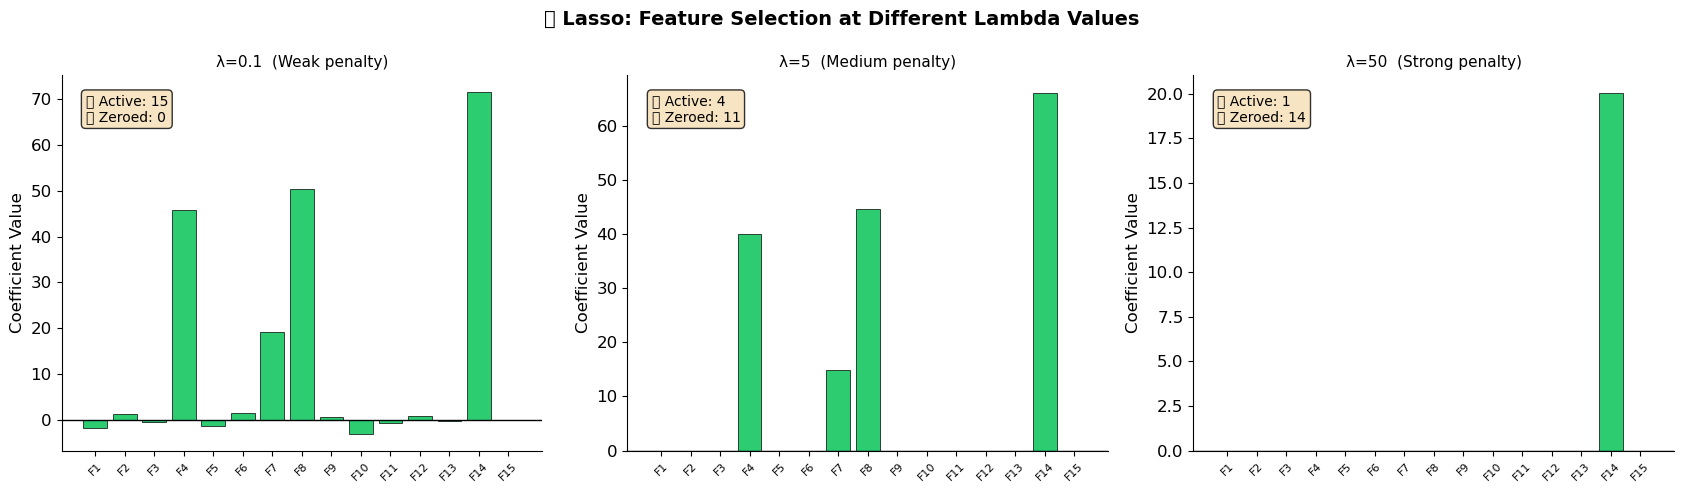

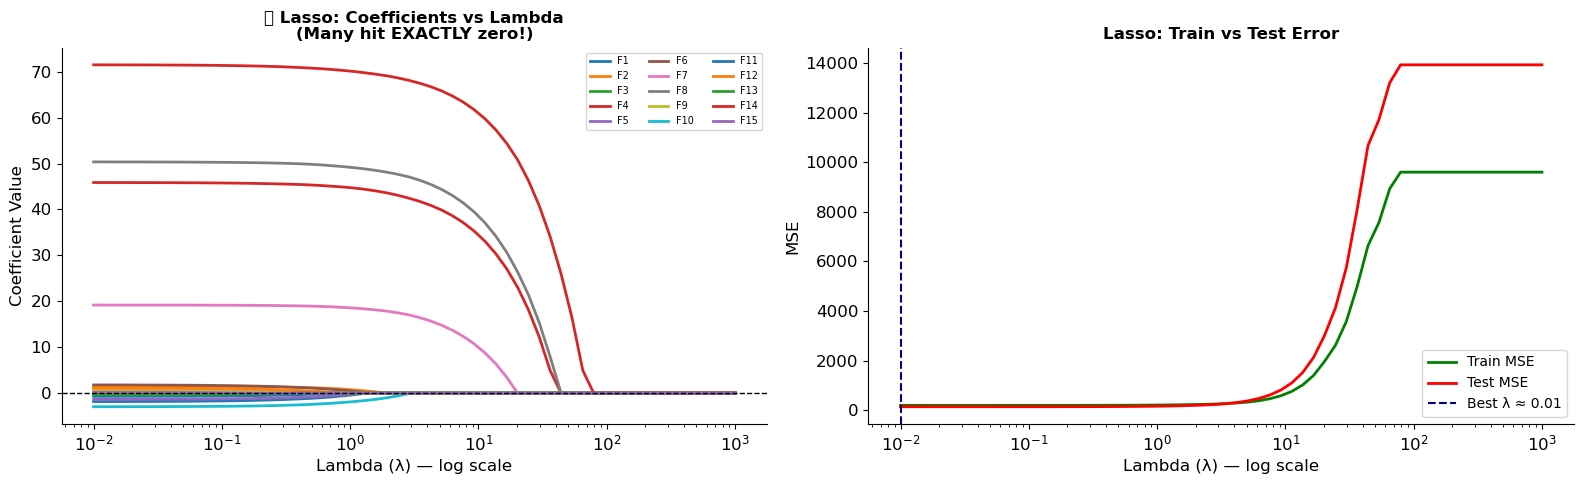


📝 KEY OBSERVATIONS for Lasso:
──────────────────────────────────────────────────────────────
  • As lambda increases, many coefficients hit EXACTLY 0.
  • Only the truly important features survive!
  • This is automatic feature selection — Lasso decides for you.
  • Best lambda ≈ 0.01
──────────────────────────────────────────────────────────────



In [6]:
# ============================================================
# 🟡 DEMO 5: Lasso — Feature Selection Power
# ============================================================

np.random.seed(42)

# Create dataset: 15 features but only 4 are truly useful
X, y = make_regression(n_samples=150, n_features=15, n_informative=4,
                       noise=15, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

feature_names = [f'Feature {i+1}' for i in range(15)]

# ── Plot 1: Coefficient bar chart for Lasso at different lambdas ──
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('🟡 Lasso: Feature Selection at Different Lambda Values',
             fontsize=14, fontweight='bold')

lasso_alphas = [0.1, 5, 50]
labels = ['λ=0.1  (Weak penalty)', 'λ=5  (Medium penalty)', 'λ=50  (Strong penalty)']

for ax, a, lbl in zip(axes, lasso_alphas, labels):
    lasso = Lasso(alpha=a, max_iter=5000)
    lasso.fit(X_train_s, y_train)
    coef = lasso.coef_
    
    bar_colors = ['#e74c3c' if abs(c) < 1e-4 else '#2ecc71' for c in coef]
    bars = ax.bar(range(len(coef)), coef, color=bar_colors, edgecolor='black', linewidth=0.5)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(lbl, fontsize=11)
    ax.set_xticks(range(len(coef)))
    ax.set_xticklabels([f'F{i+1}' for i in range(len(coef))], fontsize=8, rotation=45)
    ax.set_ylabel('Coefficient Value')
    
    n_zero    = np.sum(np.abs(coef) < 1e-4)
    n_nonzero = len(coef) - n_zero
    ax.text(0.05, 0.95, f'🟢 Active: {n_nonzero}\n🔴 Zeroed: {n_zero}',
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

# ── Plot 2: Lasso coefficient paths ──
alphas_path = np.logspace(-2, 3, 60)
coef_paths  = []

for a in alphas_path:
    las = Lasso(alpha=a, max_iter=5000)
    las.fit(X_train_s, y_train)
    coef_paths.append(las.coef_.copy())

coef_paths = np.array(coef_paths)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

for i in range(coef_paths.shape[1]):
    ax1.plot(alphas_path, coef_paths[:, i], linewidth=2, label=f'F{i+1}')
ax1.set_xscale('log')
ax1.axhline(0, color='black', linewidth=1, linestyle='--')
ax1.set_xlabel('Lambda (λ) — log scale', fontsize=12)
ax1.set_ylabel('Coefficient Value', fontsize=12)
ax1.set_title('🟡 Lasso: Coefficients vs Lambda\n(Many hit EXACTLY zero!)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=7, ncol=3, loc='upper right')

# Right: test MSE vs lambda
lasso_test_mses = []
lasso_train_mses = []
for a in alphas_path:
    las = Lasso(alpha=a, max_iter=5000)
    las.fit(X_train_s, y_train)
    lasso_train_mses.append(mean_squared_error(y_train, las.predict(X_train_s)))
    lasso_test_mses.append(mean_squared_error(y_test,  las.predict(X_test_s)))

best_lam = alphas_path[np.argmin(lasso_test_mses)]
ax2.plot(alphas_path, lasso_train_mses, 'g-', linewidth=2, label='Train MSE')
ax2.plot(alphas_path, lasso_test_mses,  'r-', linewidth=2, label='Test MSE')
ax2.axvline(best_lam, color='navy', linestyle='--', label=f'Best λ ≈ {best_lam:.2f}')
ax2.set_xscale('log')
ax2.set_xlabel('Lambda (λ) — log scale', fontsize=12)
ax2.set_ylabel('MSE', fontsize=12)
ax2.set_title('Lasso: Train vs Test Error', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"""
📝 KEY OBSERVATIONS for Lasso:
──────────────────────────────────────────────────────────────
  • As lambda increases, many coefficients hit EXACTLY 0.
  • Only the truly important features survive!
  • This is automatic feature selection — Lasso decides for you.
  • Best lambda ≈ {best_lam:.2f}
──────────────────────────────────────────────────────────────
""")

---
## 📊 Part 6: Ridge vs Lasso — Side-by-Side Comparison

---

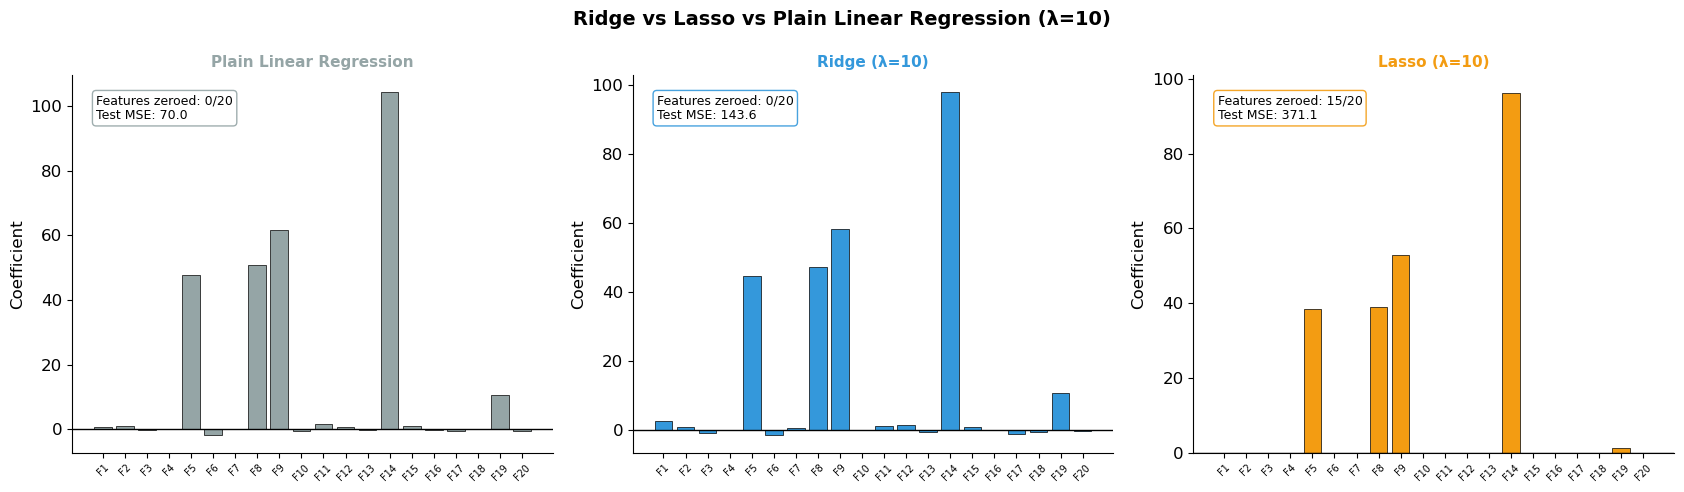


📊 RESULTS SUMMARY:
Model                            Test MSE   Zero Coefs
-------------------------------------------------------
Plain Linear Regression             69.99            0/20
Ridge (λ=10)                       143.56            0/20
Lasso (λ=10)                       371.09           15/20


In [7]:
# ============================================================
# 📊 DEMO 6: Ridge vs Lasso — Direct Comparison
# ============================================================

np.random.seed(42)

# Use same dataset with sparse features (few truly matter)
X, y = make_regression(n_samples=200, n_features=20, n_informative=5,
                       noise=10, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

alpha_val = 10  # Use the same lambda for fair comparison

ridge = Ridge(alpha=alpha_val)
lasso = Lasso(alpha=alpha_val, max_iter=10000)
lr    = LinearRegression()

ridge.fit(X_train_s, y_train)
lasso.fit(X_train_s, y_train)
lr.fit(X_train_s, y_train)

# ── Plot coefficients ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(f'Ridge vs Lasso vs Plain Linear Regression (λ={alpha_val})',
             fontsize=14, fontweight='bold')

models     = [lr,    ridge,    lasso]
mod_names  = ['Plain Linear Regression', f'Ridge (λ={alpha_val})', f'Lasso (λ={alpha_val})']
mod_colors = ['#95a5a6', '#3498db', '#f39c12']

for ax, model, name, color in zip(axes, models, mod_names, mod_colors):
    coef = model.coef_
    bar_cols = [color if abs(c) > 1e-3 else '#ecf0f1' for c in coef]
    ax.bar(range(len(coef)), coef, color=bar_cols, edgecolor='black', linewidth=0.5)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(name, fontsize=11, fontweight='bold', color=color)
    ax.set_xticks(range(len(coef)))
    ax.set_xticklabels([f'F{i+1}' for i in range(len(coef))], fontsize=7, rotation=45)
    ax.set_ylabel('Coefficient')
    
    n_zero = np.sum(np.abs(coef) < 1e-3)
    test_mse = mean_squared_error(y_test, model.predict(X_test_s))
    ax.text(0.05, 0.95,
            f'Features zeroed: {n_zero}/20\nTest MSE: {test_mse:.1f}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor=color))

plt.tight_layout()
plt.show()

# ── Summary table ──────────────────────────────────────────
print("\n📊 RESULTS SUMMARY:")
print("=" * 55)
print(f"{'Model':<30} {'Test MSE':>10} {'Zero Coefs':>12}")
print("-" * 55)
for model, name in zip([lr, ridge, lasso], mod_names):
    mse    = mean_squared_error(y_test, model.predict(X_test_s))
    n_zero = np.sum(np.abs(model.coef_) < 1e-3)
    print(f"{name:<30} {mse:>10.2f} {n_zero:>12}/20")
print("=" * 55)

---
## 🗓️ Part 7: The Grand Summary — When to Use What?

---

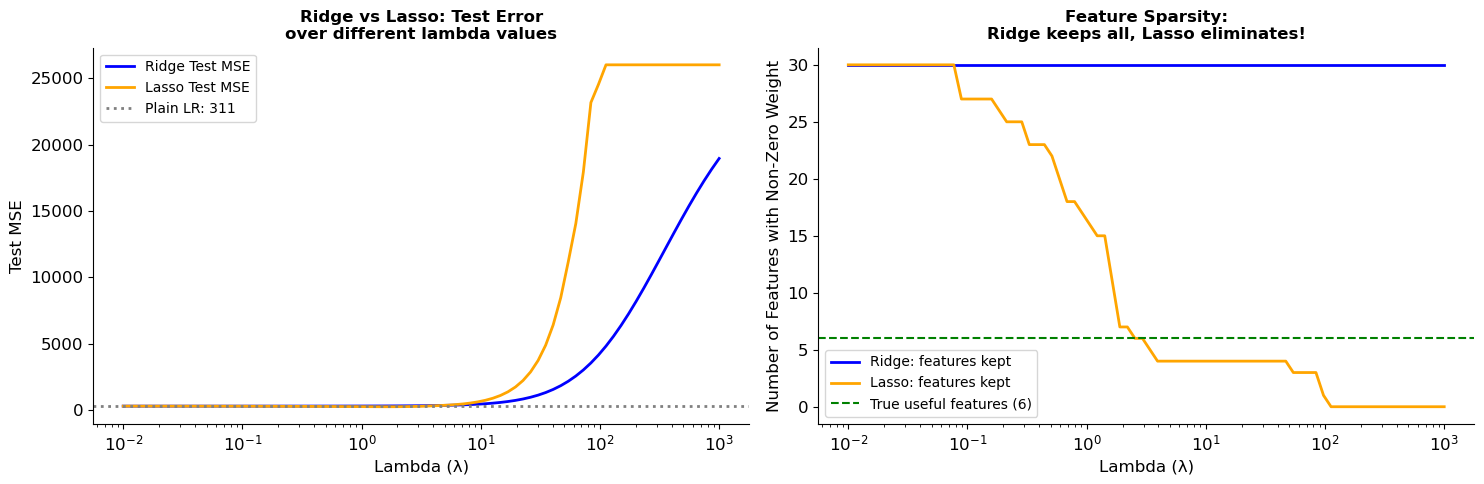


📝 FINAL OBSERVATIONS:
──────────────────────────────────────────────────────────────────
  Ridge → Keeps all 30 features even at very large lambda.
          Best when all features contribute a little bit.

  Lasso → Drops features as lambda grows. Can find the ~6 that
          really matter! Best for sparse problems with many
          irrelevant features.
──────────────────────────────────────────────────────────────────



In [8]:
# ============================================================
# 🗓️ DEMO 7: Real-world Scenario — House Price Prediction
# (Many features, some are useless noise)
# ============================================================

np.random.seed(42)

# Simulate house price dataset
# True signal: size, rooms, age matter. The rest are noise.
n_samples = 250
n_features = 30   # 30 features total
n_useful   = 6    # But only 6 are truly useful

X, y = make_regression(n_samples=n_samples, n_features=n_features,
                       n_informative=n_useful, noise=15, random_state=7)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=7)
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)
X_te_s = sc.transform(X_te)

# Try different lambda values for both Ridge and Lasso
lambda_range = np.logspace(-2, 3, 80)

ridge_test, lasso_test = [], []
ridge_feat, lasso_feat = [], []

for a in lambda_range:
    r = Ridge(alpha=a)
    l = Lasso(alpha=a, max_iter=10000)
    r.fit(X_tr_s, y_tr);  l.fit(X_tr_s, y_tr)
    ridge_test.append(mean_squared_error(y_te, r.predict(X_te_s)))
    lasso_test.append(mean_squared_error(y_te, l.predict(X_te_s)))
    ridge_feat.append(np.sum(np.abs(r.coef_) > 1e-3))
    lasso_feat.append(np.sum(np.abs(l.coef_) > 1e-3))

lr_test = mean_squared_error(y_te, LinearRegression().fit(X_tr_s,y_tr).predict(X_te_s))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(lambda_range, ridge_test, 'b-', linewidth=2, label='Ridge Test MSE')
ax1.plot(lambda_range, lasso_test, 'orange', linewidth=2, linestyle='-', label='Lasso Test MSE')
ax1.axhline(lr_test, color='gray', linestyle=':', linewidth=2, label=f'Plain LR: {lr_test:.0f}')
ax1.set_xscale('log')
ax1.set_xlabel('Lambda (λ)', fontsize=12)
ax1.set_ylabel('Test MSE', fontsize=12)
ax1.set_title('Ridge vs Lasso: Test Error\nover different lambda values', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)

ax2.plot(lambda_range, ridge_feat, 'b-', linewidth=2, label='Ridge: features kept')
ax2.plot(lambda_range, lasso_feat, 'orange', linewidth=2, label='Lasso: features kept')
ax2.axhline(n_useful, color='green', linestyle='--', linewidth=1.5, label=f'True useful features ({n_useful})')
ax2.set_xscale('log')
ax2.set_xlabel('Lambda (λ)', fontsize=12)
ax2.set_ylabel('Number of Features with Non-Zero Weight', fontsize=12)
ax2.set_title('Feature Sparsity:\nRidge keeps all, Lasso eliminates!', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("""
📝 FINAL OBSERVATIONS:
──────────────────────────────────────────────────────────────────
  Ridge → Keeps all 30 features even at very large lambda.
          Best when all features contribute a little bit.

  Lasso → Drops features as lambda grows. Can find the ~6 that
          really matter! Best for sparse problems with many
          irrelevant features.
──────────────────────────────────────────────────────────────────
""")

---
## 📋 Complete Summary: Everything in One Place

| Concept | Description | Key Sign |
|---------|-------------|----------|
| **Underfitting** | Model too simple, misses the pattern | High train error AND high test error |
| **Overfitting** | Model too complex, memorizes noise | Low train error, HIGH test error |
| **High Bias** | Systematic wrong predictions | Underfitting |
| **High Variance** | Predictions change a lot with new data | Overfitting |
| **Ridge (L2)** | Penalty = sum of squared weights | Weights shrink, never zero |
| **Lasso (L1)** | Penalty = sum of absolute weights | Weights can become exactly zero |
| **Lambda (λ)** | Controls penalty strength | Higher λ = simpler model |

---

### 🚦 Decision Guide: Which Regularization to Use?

```
                   Do you have many features?
                            │
            ┌───────────────┴───────────────┐
           YES                              NO
            │                               │
  Do you think only a FEW          Small dataset or
  features truly matter?           correlated features?
     │           │                         │
    YES          NO                       YES
     │           │                         │
   LASSO       RIDGE                    RIDGE
 (Feature    (Keep all,              (More stable
 selection)   shrink all)             with correlated
                                       features)
```

---

### 🔑 Three Key Rules to Remember:

1. **Always scale your features** before applying Ridge or Lasso (use `StandardScaler`)
2. **Use cross-validation** to find the best value of λ
3. **Ridge for dense problems** (all features matter a bit) · **Lasso for sparse problems** (few features matter a lot)

---

In [9]:
# ============================================================
# 🏁 DEMO 8: Best Practice — Finding Optimal Lambda with 
#            Cross Validation (Quick Demo)
# ============================================================

from sklearn.linear_model import RidgeCV, LassoCV

np.random.seed(42)
X, y = make_regression(n_samples=200, n_features=20, n_informative=5, noise=15, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)
X_te_s = sc.transform(X_te)

# RidgeCV & LassoCV automatically find the best lambda using cross-validation!
ridge_cv = RidgeCV(alphas=np.logspace(-2, 3, 50), cv=5)
lasso_cv = LassoCV(alphas=np.logspace(-2, 2, 50), cv=5, max_iter=10000)

ridge_cv.fit(X_tr_s, y_tr)
lasso_cv.fit(X_tr_s, y_tr)

print("🎯 Cross-Validation Results:")
print("=" * 50)
print(f"  Ridge best lambda : {ridge_cv.alpha_:.4f}")
print(f"  Lasso best lambda : {lasso_cv.alpha_:.4f}")
print()
print("📊 Test Performance:")
print("=" * 50)

# Plain LR
lr = LinearRegression().fit(X_tr_s, y_tr)
print(f"  Plain Linear Regression : MSE = {mean_squared_error(y_te, lr.predict(X_te_s)):.2f}")
print(f"  Ridge (best lambda)     : MSE = {mean_squared_error(y_te, ridge_cv.predict(X_te_s)):.2f}")
print(f"  Lasso (best lambda)     : MSE = {mean_squared_error(y_te, lasso_cv.predict(X_te_s)):.2f}")
print()
print("🔍 Features Used:")
print("=" * 50)
print(f"  Plain LR: All 20 features")
print(f"  Ridge   : All 20 features (weights shrunk)")
lasso_nonzero = np.sum(np.abs(lasso_cv.coef_) > 1e-4)
print(f"  Lasso   : {lasso_nonzero}/20 features (others zeroed out!) ✨")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ CONCLUSION:
   Regularization IMPROVES our model's performance on
   new, unseen data — that is the whole point!

   Use RidgeCV / LassoCV in practice to automatically
   find the best lambda. No guessing needed!
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

🎯 Cross-Validation Results:
  Ridge best lambda : 1.0985
  Lasso best lambda : 1.3257

📊 Test Performance:
  Plain Linear Regression : MSE = 157.48
  Ridge (best lambda)     : MSE = 156.82
  Lasso (best lambda)     : MSE = 145.05

🔍 Features Used:
  Plain LR: All 20 features
  Ridge   : All 20 features (weights shrunk)
  Lasso   : 8/20 features (others zeroed out!) ✨

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ CONCLUSION:
   Regularization IMPROVES our model's performance on
   new, unseen data — that is the whole point!

   Use RidgeCV / LassoCV in practice to automatically
   find the best lambda. No guessing needed!
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



---
## 🧪 Practice Exercises

Try these on your own to solidify your understanding!

### Exercise 1: Basic
Using the code pattern in Demo 4, create a Ridge model with `alpha=50` on a dataset with 15 features.  
Print the coefficients. Do any become zero?

### Exercise 2: Intermediate
Using `make_regression` with `n_features=25, n_informative=3`, compare:
- How many features does Lasso zero out at `alpha=5`?
- Does Ridge ever zero out features at the same alpha?

### Exercise 3: Advanced
Use `RidgeCV` and `LassoCV` on the same dataset.  
Which one gives better test MSE? Why do you think that is?

### Exercise 4: Think & Discuss
In your own words, answer:
- A friend says *"I always get 99% accuracy on my training data!"* What's the problem?
- You have a medical dataset with 500 features but only 100 samples. Which regularization would you use and why?

---

## 🏆 Final Cheat Sheet

```python
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler

# ALWAYS SCALE FIRST!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # Only transform, never fit on test!

# Ridge — manual lambda
ridge = Ridge(alpha=10)          # alpha = lambda
ridge.fit(X_train_scaled, y_train)

# Lasso — manual lambda  
lasso = Lasso(alpha=1.0)
lasso.fit(X_train_scaled, y_train)

# Auto-find best lambda with Cross Validation (RECOMMENDED!)
ridge_cv = RidgeCV(alphas=[0.1, 1, 10, 100], cv=5)
lasso_cv = LassoCV(cv=5)
ridge_cv.fit(X_train_scaled, y_train)
lasso_cv.fit(X_train_scaled, y_train)

print(f"Best Ridge lambda: {ridge_cv.alpha_}")
print(f"Best Lasso lambda: {lasso_cv.alpha_}")
```

---
*Lecture created for students who have completed Linear Regression.*  
*Next up → Elastic Net (combines Ridge + Lasso!) and Cross-Validation in depth.*

In [10]:
# ============================================================
# 📝 EXERCISE 1: Ridge Coefficient Analysis
# Goal: Observe if weights hit exactly zero with L2 penalty
# ============================================================

# 1. Generate a dataset with 15 features
# We'll use 8 informative features and some noise
X_ex1, y_ex1 = make_regression(n_samples=150, n_features=15, n_informative=8, 
                               noise=10, random_state=42)

# 2. Split into training and testing sets
X_train_ex1, X_test_ex1, y_train_ex1, y_test_ex1 = train_test_split(X_ex1, y_ex1, 
                                                                    test_size=0.2, 
                                                                    random_state=42)

# 3. Standardize features (Crucial for Regularization)
scaler_ex1 = StandardScaler()
X_train_s1 = scaler_ex1.fit_transform(X_train_ex1)
X_test_s1 = scaler_ex1.transform(X_test_ex1)

# 4. Initialize and fit Ridge model with a high alpha (alpha=50)
ridge_ex1 = Ridge(alpha=50)
ridge_ex1.fit(X_train_s1, y_train_ex1)

# 5. Output Results
print(f"--- Ridge Analysis Results (Alpha=50) ---")
print("-" * 40)
print(f"Coefficients values:\n{ridge_ex1.coef_}")

# Count how many coefficients are EXACTLY zero
zero_count = np.sum(ridge_ex1.coef_ == 0)

print("-" * 40)
print(f"Number of coefficients that are exactly zero: {zero_count}")
print(f"Smallest absolute weight: {np.min(np.abs(ridge_ex1.coef_)):.10f}")

--- Ridge Analysis Results (Alpha=50) ---
----------------------------------------
Coefficients values:
[-2.95519811  0.96360922 19.01267378 31.62504313 64.16370115  2.49093721
 13.162755   34.78450943  1.44238394  3.30172783 37.29684411 -3.10126943
 11.04619382 52.33914843  0.48806581]
----------------------------------------
Number of coefficients that are exactly zero: 0
Smallest absolute weight: 0.4880658068


In [11]:
# ============================================================
# 📝 EXERCISE 2: Lasso vs Ridge — The Sparsity Test
# Goal: Compare how many features are zeroed out by L1 vs L2
# ============================================================

# 1. Generate a dataset with 25 features, only 3 are truly useful
X_ex2, y_ex2 = make_regression(n_samples=200, n_features=25, n_informative=3, 
                               noise=15, random_state=42)

# 2. Split and Scale
X_train_ex2, X_test_ex2, y_train_ex2, y_test_ex2 = train_test_split(X_ex2, y_ex2, 
                                                                    test_size=0.2, 
                                                                    random_state=42)
scaler_ex2 = StandardScaler()
X_train_s2 = scaler_ex2.fit_transform(X_train_ex2)
X_test_s2 = scaler_ex2.transform(X_test_ex2)

# 3. Fit Lasso and Ridge with alpha=5
alpha_val = 5
lasso_ex2 = Lasso(alpha=alpha_val)
ridge_ex2 = Ridge(alpha=alpha_val)

lasso_ex2.fit(X_train_s2, y_train_ex2)
ridge_ex2.fit(X_train_s2, y_train_ex2)

# 4. Compare Results
lasso_zeros = np.sum(np.abs(lasso_ex2.coef_) < 1e-10)
ridge_zeros = np.sum(np.abs(ridge_ex2.coef_) < 1e-10)

print(f"--- Sparsity Comparison (Alpha={alpha_val}) ---")
print("-" * 45)
print(f"Lasso: Features zeroed out = {lasso_zeros} / 25")
print(f"Ridge: Features zeroed out = {ridge_zeros} / 25")

# 5. Check which features Lasso kept
print("\nLasso Non-zero Coefficient Indices:")
print(np.where(np.abs(lasso_ex2.coef_) > 1e-10)[0])

--- Sparsity Comparison (Alpha=5) ---
---------------------------------------------
Lasso: Features zeroed out = 22 / 25
Ridge: Features zeroed out = 0 / 25

Lasso Non-zero Coefficient Indices:
[17 20 22]


In [12]:
# ============================================================
# 📝 EXERCISE 3: RidgeCV vs LassoCV — The Battle of Errors
# Goal: Find optimal alpha automatically and compare test MSE
# ============================================================

from sklearn.linear_model import RidgeCV, LassoCV

# 1. Reuse the sparse dataset from Exercise 2 
# (25 features, only 3 informative)
# X_train_s2, X_test_s2, y_train_ex2, y_test_ex2 are already defined

# 2. Initialize CV models
# We provide a range of alphas for Ridge; LassoCV checks them automatically
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
lasso_cv = LassoCV(cv=5, max_iter=10000)

# 3. Fit models
ridge_cv.fit(X_train_s2, y_train_ex2)
lasso_cv.fit(X_train_s2, y_train_ex2)

# 4. Predict and Calculate MSE
ridge_test_mse = mean_squared_error(y_test_ex2, ridge_cv.predict(X_test_s2))
lasso_test_mse = mean_squared_error(y_test_ex2, lasso_cv.predict(X_test_s2))

print(f"--- Advanced CV Comparison ---")
print("-" * 40)
print(f"Best Ridge Alpha : {ridge_cv.alpha_:.4f}")
print(f"Best Lasso Alpha : {lasso_cv.alpha_:.4f}")
print("-" * 40)
print(f"Ridge Test MSE   : {ridge_test_mse:.4f}")
print(f"Lasso Test MSE   : {lasso_test_mse:.4f}")

# 5. Conclusion Logic
winner = "Lasso" if lasso_test_mse < ridge_test_mse else "Ridge"
print(f"\n🏆 The winner is: {winner}")

--- Advanced CV Comparison ---
----------------------------------------
Best Ridge Alpha : 1.2328
Best Lasso Alpha : 1.6938
----------------------------------------
Ridge Test MSE   : 259.5663
Lasso Test MSE   : 245.5080

🏆 The winner is: Lasso


# ✅ Exercise 4: Think & Discuss (Final Solutions)

---

### ❓ Question 1

**Scenario:**  
A friend says, *"I always get 99% accuracy on my training data!"*

**Answer:**  
This likely means the model is **overfitting**. Instead of learning the actual underlying pattern, the model has memorized the training data, including noise and random variations.  

Because of this, the training accuracy becomes very high, but the model usually performs poorly on new or unseen data. In other words, it fails to generalize.  

To handle this issue, techniques like **regularization (Ridge or Lasso)** can be used to keep the model simpler and reduce overfitting.

---

### ❓ Question 2

**Scenario:**  
Medical dataset with:
- 500 features  
- 100 samples  

**Answer:**  
In this case, I would choose **Lasso Regression (L1)**.  

This is a high-dimensional problem where the number of features is much larger than the number of samples. In such datasets, many features are often irrelevant or just noise.  

Lasso helps by automatically reducing the coefficients of unimportant features to zero, effectively performing feature selection.  

As a result, the model becomes simpler, more interpretable, and more useful in real-world scenarios like medical decision-making.

---